<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123657 entries, 0 to 123656
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Restaurant Name  123657 non-null  object 
 1   Dining Rating    91421 non-null   float64
 2   Delivery Rating  122377 non-null  float64
 3   Dining Votes     123657 non-null  int64  
 4   Delivery Votes   123657 non-null  int64  
 5   Cuisine          123657 non-null  object 
 6   Place Name       123657 non-null  object 
 7   City             123657 non-null  object 
 8   Item Name        123657 non-null  object 
 9   Best Seller      27942 non-null   object 
 10  Votes            123657 non-null  int64  
 11  Prices           123657 non-null  float64
dtypes: float64(3), int64(3), object(6)
memory usage: 11.3+ MB


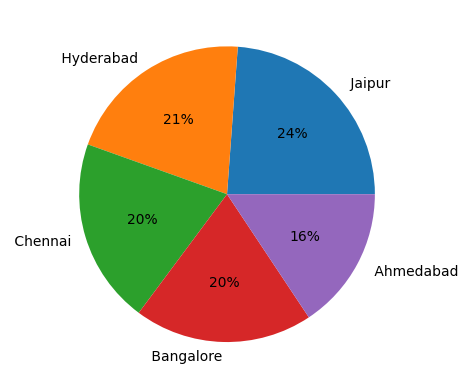

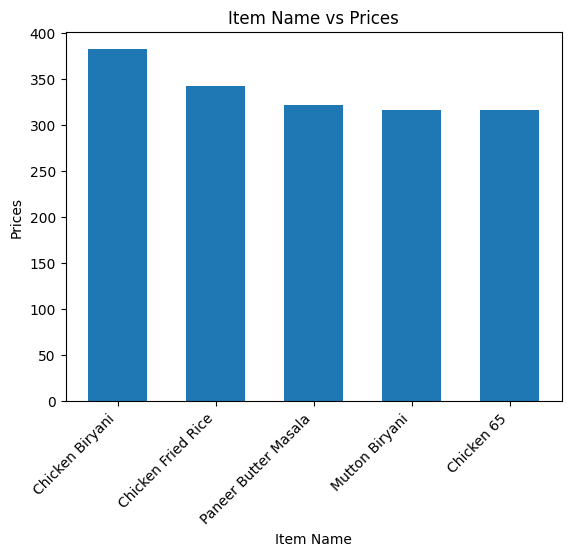

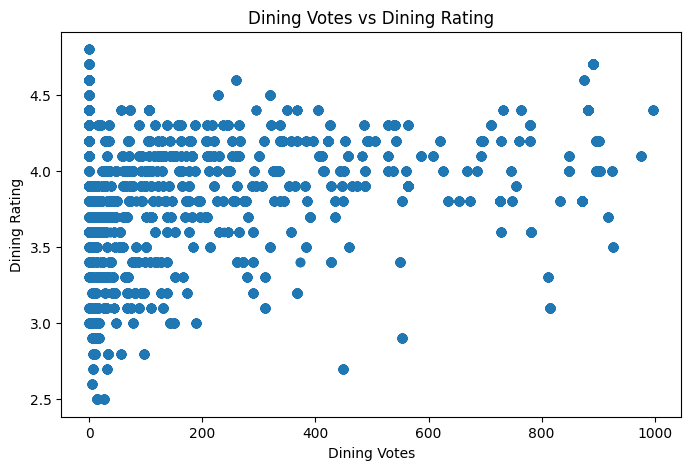

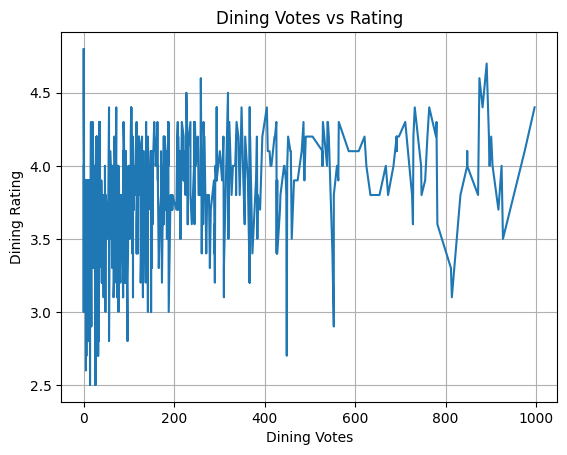

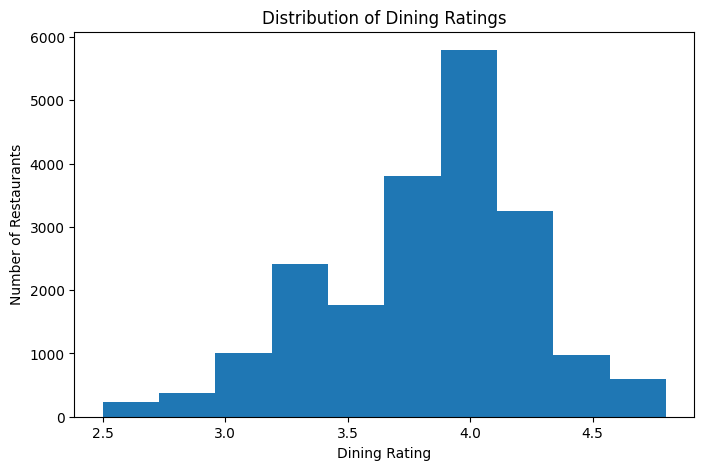

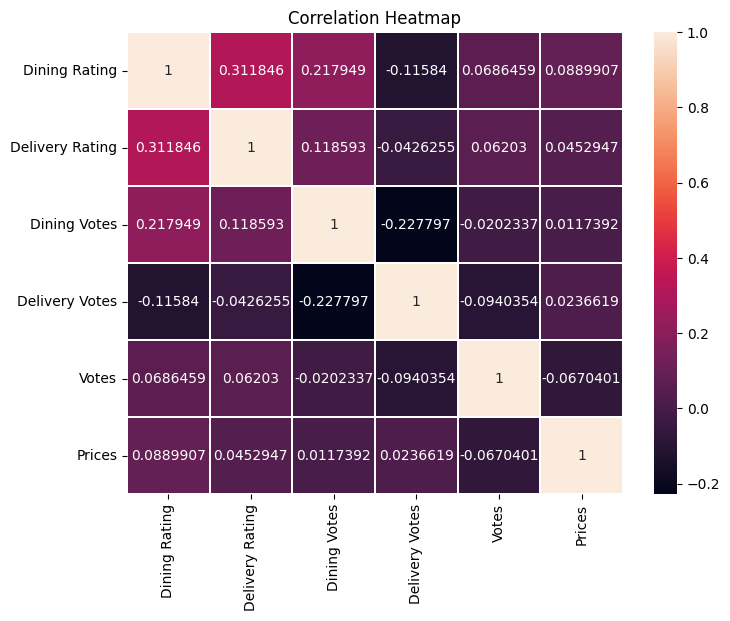

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df = pd.read_csv('zomato_dataset.csv')
df.head()
df.info()
df.isnull().sum()
df.shape
df.dropna(inplace=True)
df.shape

# visualization 1:-
df['Restaurant Name'].value_counts()
df.City.value_counts()
city_Labels = df.City.value_counts().index
city_Labels[:5]
city_values= df.City.value_counts().values
city_values[:5]
plt.pie(x=city_values[:5],labels=city_Labels[:5],autopct="%1.0f%%")
plt.show()

# visualization 2:-
df['Item Name'].value_counts()
df['Prices'].value_counts()
city_Labels = df['Prices'].value_counts().index
city_Labels[:5]
city_values= df['Prices'].value_counts().values
city_values[:5]
plt.xlabel('Item Name')
plt.ylabel('Prices')
plt.title("Item Name vs Prices")
plt.bar(x= df['Item Name'].value_counts().index[:5], height=city_values[:5],  width=0.6)
plt.xticks(rotation=45, ha='right')
plt.show()

# visualization 3:-
df = df.dropna(subset=['Dining Votes', 'Dining Rating'])
plt.figure(figsize=(8,5))
plt.scatter(df['Dining Votes'], df['Dining Rating'])
plt.xlabel("Dining Votes")
plt.ylabel("Dining Rating")
plt.title("Dining Votes vs Dining Rating")
plt.show()

# visualization 4:-
df = df.dropna(subset=['Dining Votes', 'Dining Rating'])
df = df.sort_values(by='Dining Votes')
plt.plot(df['Dining Votes'], df['Dining Rating'])
plt.xlabel("Dining Votes")
plt.ylabel("Dining Rating")
plt.title("Dining Votes vs Rating")
plt.grid(True)
plt.show()

# visualization 5:-
df = df.dropna(subset=['Dining Rating'])
plt.figure(figsize=(8,5))
plt.hist(df['Dining Rating'], bins=10)
plt.xlabel("Dining Rating")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Dining Ratings")
plt.show()

# visualization 6:-
cols = ['Dining Rating', 'Delivery Rating', 'Dining Votes', 
        'Delivery Votes', 'Votes', 'Prices']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df[cols].dropna()
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, linewidths=0.1, annot=True, fmt='0g' )
plt.title("Correlation Heatmap")
plt.show()

# visualization 7:-
df = df.dropna(subset=['Dining Votes', 'Dining Rating'])
df = df.sort_values(by='Dining Votes')
fig = px.area(df, x="Dining Votes", y="Dining Rating", line_group="Prices")
fig.show()

